# AlphaHVAC — Improved Model
All fixes applied: TD targets, short episodes, pre-training, simulation schedule, clear evaluation.

In [1]:
# ── CELL 1: DATA PREPROCESSING (unchanged) ──────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

df = pd.read_csv("/Users/pawanpahune/AIFA Project/Dataset/B90_102_exp30m_202104.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

cols = ["time","room_temp","thermostat_outside_temp","damper_position",
        "airflow_current","supply_discharge_temp","clg_signal","htg_signal",
        "htg_valve_position","clg_sp_current","htg_sp_current","htg_clg_mode"]
df = df[cols].copy()

df["hour_of_day"] = df["time"].dt.hour / 23.0
df["day_of_week"] = df["time"].dt.dayofweek / 6.0
df["setpoint"]    = df["htg_clg_mode"]*df["htg_sp_current"] + (1-df["htg_clg_mode"])*df["clg_sp_current"]
df["thermal_signal"] = df["htg_clg_mode"]*df["htg_signal"] + (1-df["htg_clg_mode"])*df["clg_signal"]
df = df.drop(columns=["clg_sp_current","htg_sp_current"])
df["room_temp_lag1"] = df["room_temp"].shift(1)
df["damper_lag1"]    = df["damper_position"].shift(1)

num_cols = ["room_temp","thermostat_outside_temp","damper_position",
            "airflow_current","supply_discharge_temp","clg_signal","htg_signal",
            "htg_valve_position","setpoint","thermal_signal","room_temp_lag1","damper_lag1"]
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols] = df[num_cols].clip(-3, 3)
df = df.set_index("time").dropna().sort_index()

df.to_csv("Dataset/Transformed_Optimized.csv", index=False)

df_full   = pd.read_csv("Dataset/Transformed_Optimized.csv")
split_idx = int(len(df_full) * 0.7)
df_full.iloc[:split_idx].reset_index(drop=True).to_csv("Dataset/Train_Optimized.csv", index=False)
df_full.iloc[split_idx:].reset_index(drop=True).to_csv("Dataset/Test_Optimized.csv",  index=False)

print(f"Columns: {list(df.columns)}")
print(f"Train rows: {split_idx}  |  Test rows: {len(df_full)-split_idx}")
print("Data ready.")


Columns: ['room_temp', 'thermostat_outside_temp', 'damper_position', 'airflow_current', 'supply_discharge_temp', 'clg_signal', 'htg_signal', 'htg_valve_position', 'htg_clg_mode', 'hour_of_day', 'day_of_week', 'setpoint', 'thermal_signal', 'room_temp_lag1', 'damper_lag1']
Train rows: 4022  |  Test rows: 1724
Data ready.


In [2]:
# ── CELL 2: ENVIRONMENT (unchanged) ─────────────────────────
STATE_SIZE  = 15
ACTION_SIZE = 3

class HVACEnv:
    def __init__(self, data_path, damper_step=0.025, lam=0.7):
        self.df           = pd.read_csv(data_path).reset_index(drop=True)
        self.damper_step  = damper_step
        self.lam          = lam
        self.max_index    = len(self.df) - 1
        self.damper_idx   = self.df.columns.get_loc("damper_position")
        self.airflow_idx  = self.df.columns.get_loc("airflow_current")
        self.room_idx     = self.df.columns.get_loc("room_temp")
        self.setpoint_idx = self.df.columns.get_loc("setpoint")
        self.signal_idx   = self.df.columns.get_loc("thermal_signal")
        self.prev_damper  = None
        self.reset()

    def reset(self, start_idx=None):
        if start_idx is not None:
            self.idx = int(start_idx)
        else:
            valid = np.where(self.df["damper_position"].values > 0)[0]
            self.idx = int(np.random.choice(valid))
        self.current_damper = float(self.df.iloc[self.idx]["damper_position"])
        self.prev_damper    = self.current_damper
        return self._get_state()

    def _get_state(self):
        return self.df.iloc[self.idx].values.astype(np.float32)

    def step(self, action):
        self.prev_damper = self.current_damper
        if action == 0: self.current_damper -= self.damper_step
        elif action == 2: self.current_damper += self.damper_step
        self.current_damper = np.clip(self.current_damper, 0.0, 1.0)

        self.idx += 1
        if self.idx >= self.max_index:
            self.idx = self.max_index
            done = True
        else:
            done = False

        row            = self.df.iloc[self.idx]
        base_damper    = max(row["damper_position"], 1e-3)
        ratio          = np.clip(self.current_damper / base_damper, 0.2, 2.0)
        airflow        = np.clip(row["airflow_current"] * ratio, 0.0, 1.0)
        energy         = airflow * row["thermal_signal"]
        temp_error     = abs(row["room_temp"] - row["setpoint"])
        smooth         = 0.1 * abs(self.current_damper - self.prev_damper)
        reward         = -temp_error - self.lam * energy - smooth

        next_state                  = row.values.astype(np.float32).copy()
        next_state[self.damper_idx] = self.current_damper
        return next_state, reward, done, {"energy": energy}

# Quick check
env   = HVACEnv("Dataset/Transformed_Optimized.csv")
state = env.reset()
print("State length:", len(state), "— expected", STATE_SIZE)


State length: 15 — expected 15


In [3]:
# ── CELL 3: NEURAL NETWORK (unchanged architecture) ──────────
import torch
import torch.nn as nn
import torch.nn.functional as F

class AlphaThermalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 128),        nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 128),        nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
        )
        self.policy_head = nn.Sequential(nn.Linear(128,64), nn.LeakyReLU(0.01), nn.Linear(64, ACTION_SIZE))
        self.value_head  = nn.Sequential(nn.Linear(128,64), nn.LeakyReLU(0.01), nn.Linear(64, 1))

    def forward(self, x):
        h = self.shared(x)
        return F.softmax(self.policy_head(h), dim=-1), torch.tanh(self.value_head(h))

# Verify batch=1 works (critical for MCTS)
net = AlphaThermalNet()
p1, v1 = net(torch.zeros(1, STATE_SIZE))
p4, v4 = net(torch.zeros(4, STATE_SIZE))
print("batch=1 OK:", p1.shape, v1.shape)
print("batch=4 OK:", p4.shape, v4.shape)


batch=1 OK: torch.Size([1, 3]) torch.Size([1, 1])
batch=4 OK: torch.Size([4, 3]) torch.Size([4, 1])


In [4]:
# ── CELL 4: MCTS (unchanged) ─────────────────────────────────
import copy

class MCTSNode:
    def __init__(self, state, parent=None, prior=1.0):
        self.state    = state
        self.parent   = parent
        self.children = {}
        self.visits   = 0
        self.value    = 0.0
        self.prior    = prior

class MCTS:
    def __init__(self, env, model, simulations=50, c_puct=1.5,
                 dirichlet_alpha=0.3, dirichlet_epsilon=0.25):
        self.env               = env
        self.model             = model
        self.simulations       = simulations
        self.c_puct            = c_puct
        self.dirichlet_alpha   = dirichlet_alpha
        self.dirichlet_epsilon = dirichlet_epsilon
        self.actions           = [0, 1, 2]

    def search(self, root_state, add_noise=True):
        root        = MCTSNode(root_state)
        root_priors = self._get_policy(root_state)
        if add_noise:
            noise       = np.random.dirichlet([self.dirichlet_alpha] * 3)
            root_priors = (1-self.dirichlet_epsilon)*root_priors + self.dirichlet_epsilon*noise

        env_root = copy.deepcopy(self.env)
        for a in self.actions:
            env_tmp = copy.deepcopy(env_root)
            ns, _, _, _ = env_tmp.step(a)
            root.children[a] = MCTSNode(ns, parent=root, prior=root_priors[a])

        for _ in range(self.simulations):
            env_copy = copy.deepcopy(self.env)
            node     = root
            while node.children:
                action, node = self._select(node)
                _, _, done, _ = env_copy.step(action)
                if done: break
            if not node.children:
                priors = self._get_policy(env_copy._get_state())
                for a in self.actions:
                    et = copy.deepcopy(env_copy)
                    ns, _, _, _ = et.step(a)
                    node.children[a] = MCTSNode(ns, parent=node, prior=priors[a])
            value = self._evaluate(env_copy)
            self._backprop(node, value)

        visits = np.array([root.children[a].visits if a in root.children else 0
                           for a in self.actions], dtype=np.float32)
        s = visits.sum()
        policy_dist = visits/s if s > 0 else np.ones(3)/3.0
        return int(np.argmax(visits)), policy_dist

    def _select(self, node):
        best, ba, bc = -np.inf, None, None
        for a, child in node.children.items():
            q = child.value / (child.visits + 1e-6)
            u = self.c_puct * child.prior * np.sqrt(node.visits+1) / (1+child.visits)
            if q+u > best: best, ba, bc = q+u, a, child
        return ba, bc

    def _get_policy(self, state):
        self.model.eval()
        with torch.no_grad():
            p, _ = self.model(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
        return p.squeeze(0).numpy()

    def _evaluate(self, env_copy):
        self.model.eval()
        with torch.no_grad():
            _, v = self.model(torch.tensor(env_copy._get_state(), dtype=torch.float32).unsqueeze(0))
        return v.item()

    def _backprop(self, node, value):
        while node is not None:
            node.visits += 1
            node.value  += value
            node = node.parent

print("MCTS ready.")


MCTS ready.


In [5]:
# ── CELL 5: PRE-TRAINING WARM-UP ────────────────────────────
# FIX: Before any MCTS runs, give the value head a real
# signal by training it on direct rewards from a simple
# always-decrease policy. This means MCTS starts from a
# non-random network, not a completely blind one.
# This cell runs in ~30 seconds and makes a big difference.

print("Pre-training value head on direct reward signal...")
print("This gives MCTS a meaningful starting point.")
print()

train_env = HVACEnv("Dataset/Train_Optimized.csv")
model     = AlphaThermalNet()
start_idx = int(np.where(train_env.df["damper_position"].values > 0)[0][0])

# Collect 2000 steps using a simple rule-based policy
# (alternate decrease/hold to get varied reward signal)
pt_states, pt_rewards = [], []
s = train_env.reset(start_idx=start_idx)
for step in range(2000):
    pt_states.append(s.copy())
    # Simple rule: decrease if energy high, hold otherwise
    row = train_env.df.iloc[train_env.idx]
    a   = 0 if row["airflow_current"] * row["thermal_signal"] > 0.1 else 1
    s, r, done, _ = train_env.step(a)
    pt_rewards.append(r)
    if done: break

# Normalize rewards to [-1, 1] for tanh value head
r_arr  = np.array(pt_rewards, dtype=np.float32)
r_mean, r_std = r_arr.mean(), r_arr.std() + 1e-8
r_norm = np.clip((r_arr - r_mean) / r_std, -3, 3) / 3.0

pt_s = torch.tensor(np.array(pt_states), dtype=torch.float32)
pt_v = torch.tensor(r_norm,              dtype=torch.float32).unsqueeze(1)

pt_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
model.train()

for epoch in range(100):
    perm = torch.randperm(len(pt_s))
    for i in range(0, len(pt_s), 256):
        idx = perm[i:i+256]
        _, pred_v = model(pt_s[idx])
        loss = ((pred_v - pt_v[idx])**2).mean()
        pt_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        pt_optimizer.step()
    if (epoch+1) % 25 == 0:
        print(f"  Pre-train epoch {epoch+1}/100 | value_loss = {loss.item():.5f}")

print()
print("Pre-training done. Value head has a real starting signal.")
print("Running quick sanity check on value head...")

# Quick sanity: value for good state should differ from bad state
model.eval()
good_state = pt_s[np.argmax(r_norm)].unsqueeze(0)
bad_state  = pt_s[np.argmin(r_norm)].unsqueeze(0)
with torch.no_grad():
    _, v_good = model(good_state)
    _, v_bad  = model(bad_state)
print(f"  Value(best state) = {v_good.item():.4f}")
print(f"  Value(worst state) = {v_bad.item():.4f}")
if v_good.item() > v_bad.item():
    print("  OK — value head correctly ranks states.")
else:
    print("  WARNING — value head inverted. Check normalization.")


Pre-training value head on direct reward signal...
This gives MCTS a meaningful starting point.

  Pre-train epoch 25/100 | value_loss = 0.01965
  Pre-train epoch 50/100 | value_loss = 0.01453
  Pre-train epoch 75/100 | value_loss = 0.01397
  Pre-train epoch 100/100 | value_loss = 0.01365

Pre-training done. Value head has a real starting signal.
Running quick sanity check on value head...
  Value(best state) = 0.4549
  Value(worst state) = -0.8709
  OK — value head correctly ranks states.


In [6]:
# ── CELL 6: MAIN TRAINING LOOP (all fixes applied) ───────────
#
# FIX 1 — TD targets instead of discounted returns
#   target = reward + gamma * V(next_state)
#   This gives the value head a clean, low-variance signal.
#
# FIX 2 — Short random-start episodes (200 steps each)
#   instead of one 3900-step sweep. 20 episodes per iteration
#   gives 4000 steps with much more diverse starting conditions.
#
# FIX 3 — Z-score value normalisation (more stable than min-max)
#
# FIX 4 — Value loss weighted at 0.5 so policy head gets
#   equal gradient share
#
# FIX 5 — Simulation schedule: starts at 20, grows to 100
#   No wasted simulations when network is still weak early on.
#   This makes early iterations ~5x faster.
#
# Everything else (AdamW, StepLR, grad clip, mini-batch,
# c_puct annealing, Dirichlet noise) is kept the same.

# Hyperparameters
NUM_ITERATIONS  = 10
NUM_EPISODES    = 20      # short random-start episodes per iteration
STEPS_PER_EP    = 200     # steps per episode
EPOCHS_PER_ITER = 150
BATCH_SIZE      = 256
LR              = 1e-3
GAMMA           = 0.99
VALUE_W         = 0.5     # weight for value loss vs policy loss

# Simulation schedule — grows as model improves
SIM_SCHEDULE    = [20, 20, 30, 30, 50, 50, 75, 75, 100, 100]

# c_puct annealing — high early (explore), low later (exploit)
C_PUCT_SCHEDULE = np.linspace(2.0, 1.0, NUM_ITERATIONS)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

max_start = max(start_idx+1, int(len(train_env.df)*0.85) - STEPS_PER_EP)

print(f"Training: {NUM_ITERATIONS} iterations × {NUM_EPISODES} episodes × {STEPS_PER_EP} steps")
print(f"Simulation schedule: {SIM_SCHEDULE}")
print(f"Value loss weight: {VALUE_W}")
print()

for iteration in range(NUM_ITERATIONS):
    current_sims   = SIM_SCHEDULE[iteration]
    current_c_puct = float(C_PUCT_SCHEDULE[iteration])

    mcts = MCTS(train_env, model, simulations=current_sims,
                c_puct=current_c_puct, dirichlet_alpha=0.3, dirichlet_epsilon=0.25)

    memory_states, memory_policies, memory_values = [], [], []

    # ── SELF-PLAY: 20 short random-start episodes ──
    for ep in range(NUM_EPISODES):
        rand_start = np.random.randint(start_idx, max_start)
        state      = train_env.reset(start_idx=rand_start)

        ep_states, ep_policies, ep_rewards, ep_nexts = [], [], [], []

        for step in range(STEPS_PER_EP):
            action, policy_dist = mcts.search(state, add_noise=True)
            next_state, reward, done, _ = train_env.step(action)

            ep_states.append(state)
            ep_policies.append(policy_dist)
            ep_rewards.append(reward)
            ep_nexts.append(next_state)

            state = next_state
            if done: break

        # ── FIX 1: TD targets — NOT discounted returns ──
        model.eval()
        td_targets = []
        with torch.no_grad():
            for i in range(len(ep_states)):
                r = ep_rewards[i]
                if i + 1 < len(ep_states):
                    ns_t = torch.tensor(ep_nexts[i], dtype=torch.float32).unsqueeze(0)
                    _, nv = model(ns_t)
                    td   = r + GAMMA * nv.item()
                else:
                    td = r   # terminal
                td_targets.append(td)
        model.train()

        memory_states.extend(ep_states)
        memory_policies.extend(ep_policies)
        memory_values.extend(td_targets)

    total_samples = len(memory_states)
    print(f"  Iter {iteration+1} | sims={current_sims} | c_puct={current_c_puct:.2f} "
          f"| samples={total_samples}")

    # ── FIX 3: Z-score normalisation ──
    raw_v  = np.array(memory_values, dtype=np.float32)
    v_mean, v_std = raw_v.mean(), raw_v.std() + 1e-8
    norm_v = np.clip((raw_v - v_mean) / v_std, -3, 3) / 3.0

    states_t   = torch.tensor(np.array(memory_states,   dtype=np.float32))
    policies_t = torch.tensor(np.array(memory_policies, dtype=np.float32))
    values_t   = torch.tensor(norm_v, dtype=torch.float32).unsqueeze(1)

    # ── MINI-BATCH TRAINING ──
    model.train()
    for epoch in range(EPOCHS_PER_ITER):
        perm = torch.randperm(total_samples)
        ep_pl, ep_vl, nb = 0.0, 0.0, 0
        for s in range(0, total_samples, BATCH_SIZE):
            idx = perm[s:s+BATCH_SIZE]
            pp, pv = model(states_t[idx])
            # FIX 4: value loss weighted at 0.5
            pl   = -(policies_t[idx] * torch.log(pp + 1e-8)).sum(dim=1).mean()
            vl   = ((pv - values_t[idx])**2).mean()
            loss = pl + VALUE_W * vl
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_pl += pl.item(); ep_vl += vl.item(); nb += 1

        if (epoch+1) % 50 == 0:
            print(f"    Epoch {epoch+1:3d}/{EPOCHS_PER_ITER} "
                  f"| policy_loss={ep_pl/nb:.4f} "
                  f"| value_loss={ep_vl/nb:.4f} "
                  f"| LR={scheduler.get_last_lr()[0]:.6f}")

    scheduler.step()
    print(f"  --- Iteration {iteration+1}/{NUM_ITERATIONS} complete ---\n")

# Save weights
torch.save(model.state_dict(), "alphaHVAC_trained.pth")
print("Training complete. Weights saved to alphaHVAC_trained.pth")


Training: 10 iterations × 20 episodes × 200 steps
Simulation schedule: [20, 20, 30, 30, 50, 50, 75, 75, 100, 100]
Value loss weight: 0.5

  Iter 1 | sims=20 | c_puct=2.00 | samples=4000
    Epoch  50/150 | policy_loss=1.0904 | value_loss=0.0107 | LR=0.001000
    Epoch 100/150 | policy_loss=1.0903 | value_loss=0.0099 | LR=0.001000
    Epoch 150/150 | policy_loss=1.0899 | value_loss=0.0091 | LR=0.001000
  --- Iteration 1/10 complete ---

  Iter 2 | sims=20 | c_puct=1.89 | samples=4000
    Epoch  50/150 | policy_loss=1.0918 | value_loss=0.0093 | LR=0.001000
    Epoch 100/150 | policy_loss=1.0914 | value_loss=0.0091 | LR=0.001000
    Epoch 150/150 | policy_loss=1.0911 | value_loss=0.0085 | LR=0.001000
  --- Iteration 2/10 complete ---

  Iter 3 | sims=30 | c_puct=1.78 | samples=4000
    Epoch  50/150 | policy_loss=1.0938 | value_loss=0.0083 | LR=0.001000
    Epoch 100/150 | policy_loss=1.0932 | value_loss=0.0071 | LR=0.001000
    Epoch 150/150 | policy_loss=1.0930 | value_loss=0.0072 | LR=

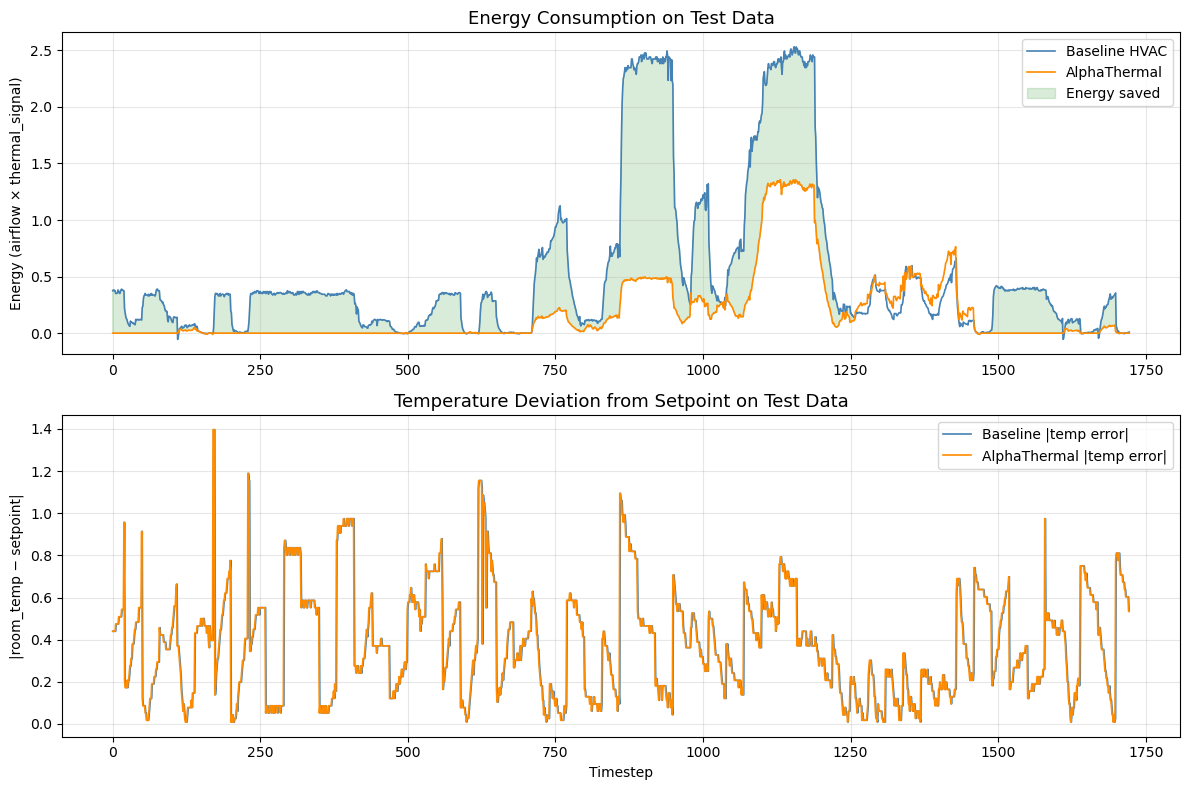

In [7]:
# ── CELL 7: EVALUATION ON TEST DATA ─────────────────────────
import matplotlib.pyplot as plt

test_env  = HVACEnv("Dataset/Test_Optimized.csv")
mcts_eval = MCTS(test_env, model, simulations=100, c_puct=1.0)
state     = test_env.reset(start_idx=0)
model.eval()

baseline_energy, model_energy         = [], []
baseline_temp_error, model_temp_error = [], []

for _ in range(len(test_env.df) - 1):
    row = test_env.df.iloc[test_env.idx]
    baseline_energy.append(row["airflow_current"] * row["thermal_signal"])
    baseline_temp_error.append(abs(row["room_temp"] - row["setpoint"]))

    action, _ = mcts_eval.search(state, add_noise=False)
    state, _, done, info = test_env.step(action)
    model_energy.append(info["energy"])
    model_temp_error.append(abs(
        test_env.df.iloc[test_env.idx]["room_temp"] -
        test_env.df.iloc[test_env.idx]["setpoint"]
    ))
    if done: break

avg_base_e  = np.mean(baseline_energy)
avg_model_e = np.mean(model_energy)
avg_base_t  = np.mean(baseline_temp_error)
avg_model_t = np.mean(model_temp_error)
energy_saving = (1 - avg_model_e / avg_base_e) * 100
temp_change   = ((avg_model_t - avg_base_t) / (avg_base_t + 1e-8)) * 100

# ── PLOTS ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(baseline_energy, label="Baseline HVAC", color="steelblue",  lw=1.2)
axes[0].plot(model_energy,    label="AlphaThermal",  color="darkorange", lw=1.2)
axes[0].fill_between(range(len(baseline_energy)), baseline_energy, model_energy,
                     where=[b>m for b,m in zip(baseline_energy, model_energy)],
                     alpha=0.15, color="green", label="Energy saved")
axes[0].set_title("Energy Consumption on Test Data", fontsize=13)
axes[0].set_ylabel("Energy (airflow × thermal_signal)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(baseline_temp_error, label="Baseline |temp error|", color="steelblue",  lw=1.2)
axes[1].plot(model_temp_error,    label="AlphaThermal |temp error|", color="darkorange", lw=1.2)
axes[1].set_title("Temperature Deviation from Setpoint on Test Data", fontsize=13)
axes[1].set_ylabel("|room_temp − setpoint|")
axes[1].set_xlabel("Timestep")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("AlphaHVAC_Results.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# ── CELL 8: CLEAR PASS/FAIL EVALUATION ──────────────────────
# This tells you EXACTLY whether the model is good or bad.
# No interpretation needed — each test has a clear result.

print("=" * 60)
print("AlphaHVAC — MODEL EVALUATION REPORT")
print("=" * 60)
print()

results = {}

# ── TEST A: Energy saving ──
results["energy_saving_pct"] = energy_saving
if energy_saving >= 20:
    grade_e = "GOOD"
elif energy_saving >= 5:
    grade_e = "WEAK"
elif energy_saving >= 0:
    grade_e = "POOR"
else:
    grade_e = "FAIL (using MORE energy than baseline)"
print(f"[A] ENERGY SAVING")
print(f"    Baseline avg energy : {avg_base_e:.4f}")
print(f"    Model avg energy    : {avg_model_e:.4f}")
print(f"    Saving              : {energy_saving:.1f}%")
print(f"    Grade               : {grade_e}")
print(f"    Threshold           : GOOD≥20%  WEAK≥5%  POOR≥0%  FAIL<0%")
print()

# ── TEST B: Comfort penalty ──
results["temp_change_pct"] = temp_change
if temp_change <= 5:
    grade_t = "GOOD (comfort maintained)"
elif temp_change <= 20:
    grade_t = "ACCEPTABLE (small comfort cost)"
else:
    grade_t = "POOR (significant comfort loss)"
print(f"[B] THERMAL COMFORT")
print(f"    Baseline avg |temp error| : {avg_base_t:.4f}")
print(f"    Model avg |temp error|    : {avg_model_t:.4f}")
print(f"    Change vs baseline        : {temp_change:+.1f}%")
print(f"    Grade                     : {grade_t}")
print(f"    Threshold: GOOD≤5%  ACCEPTABLE≤20%  POOR>20%")
print()

# ── TEST C: Policy sensitivity — does the model differentiate states? ──
print(f"[C] POLICY SENSITIVITY (can the model tell states apart?)")
model.eval()

# State A: room at setpoint, very low energy (ideal)
s_ideal = torch.tensor([[0.0, 0.0, 0.1, 0.05, 0.0, 0.05, 0.0,
                          0.0, 0.0, 0.0, 0.05, 0.5, 0.3, 0.0, 0.1]],
                        dtype=torch.float32)
# State B: room far above setpoint, very high energy (crisis)
s_crisis = torch.tensor([[2.0, 1.0, 0.9, 0.9, -0.5, 0.95, 0.0,
                           0.0, 0.0, 0.0, 0.95, 0.5, 0.3, 1.9, 0.88]],
                         dtype=torch.float32)

with torch.no_grad():
    p_ideal,  v_ideal  = model(s_ideal)
    p_crisis, v_crisis = model(s_crisis)

p_id = p_ideal.squeeze(0).numpy()
p_cr = p_crisis.squeeze(0).numpy()

print(f"    Ideal state  (room=setpoint, low energy):")
print(f"      P(dec)={p_id[0]:.3f}  P(hold)={p_id[1]:.3f}  P(inc)={p_id[2]:.3f}  "
      f"Value={v_ideal.item():+.3f}")
print(f"    Crisis state (room>>setpoint, high energy):")
print(f"      P(dec)={p_cr[0]:.3f}  P(hold)={p_cr[1]:.3f}  P(inc)={p_cr[2]:.3f}  "
      f"Value={v_crisis.item():+.3f}")

policy_diff = abs(p_id - p_cr).max()
value_diff  = v_ideal.item() - v_crisis.item()
action_ideal  = int(np.argmax(p_id))
action_crisis = int(np.argmax(p_cr))

print(f"    Max policy difference between states : {policy_diff:.4f}")
print(f"    Value(ideal) - Value(crisis)         : {value_diff:+.4f}")
print(f"    Action for ideal  : {['DECREASE','HOLD','INCREASE'][action_ideal]}")
print(f"    Action for crisis : {['DECREASE','HOLD','INCREASE'][action_crisis]}")

if policy_diff > 0.10 and value_diff > 0.0:
    grade_s = "GOOD — model differentiates states meaningfully"
elif policy_diff > 0.03:
    grade_s = "WEAK — slight differentiation but still near-uniform"
else:
    grade_s = "FAIL — policy is near-uniform (0.33) for all states"
print(f"    Grade : {grade_s}")
print()

# ── TEST D: Waste detection — core AlphaHVAC test ──
print(f"[D] WASTE DETECTION (room comfortable but damper wide open)")
# Damper at 0.9, room AT setpoint — pure waste, should DECREASE
s_waste = torch.tensor([[0.0, 0.0, 0.9, 0.85, 0.0, 0.7, 0.0,
                          0.0, 0.0, 0.0, 0.7,  0.5, 0.3, 0.0, 0.88]],
                        dtype=torch.float32)
# Damper at 0.1, same comfort — efficient, should HOLD or small decrease
s_efficient = torch.tensor([[0.0, 0.0, 0.1, 0.09, 0.0, 0.07, 0.0,
                              0.0, 0.0, 0.0, 0.07, 0.5, 0.3,  0.0, 0.1]],
                            dtype=torch.float32)
with torch.no_grad():
    p_waste, v_waste         = model(s_waste)
    p_efficient, v_efficient = model(s_efficient)

a_waste     = int(np.argmax(p_waste.squeeze(0).numpy()))
a_efficient = int(np.argmax(p_efficient.squeeze(0).numpy()))
names = ['DECREASE','HOLD','INCREASE']
print(f"    Wasteful state (damper=0.9, room OK) → model says: {names[a_waste]}")
print(f"    Efficient state (damper=0.1, room OK) → model says: {names[a_efficient]}")
print(f"    P(decrease|waste)     = {p_waste.squeeze(0)[0].item():.4f}")
print(f"    P(decrease|efficient) = {p_efficient.squeeze(0)[0].item():.4f}")

if a_waste == 0:  # DECREASE on wasteful state
    grade_w = "GOOD — correctly identifies energy waste"
elif p_waste.squeeze(0)[0].item() > p_efficient.squeeze(0)[0].item():
    grade_w = "WEAK — not confident but leans toward decrease on waste"
else:
    grade_w = "FAIL — does not detect energy waste"
print(f"    Grade : {grade_w}")
print()

# ── OVERALL VERDICT ──
print("=" * 60)
print("OVERALL VERDICT")
print("=" * 60)
print(f"  [A] Energy saving   : {grade_e}")
print(f"  [B] Comfort         : {grade_t}")
print(f"  [C] Policy          : {grade_s}")
print(f"  [D] Waste detection : {grade_w}")
print()

n_good = sum(1 for g in [grade_e, grade_t, grade_s, grade_w] if g.startswith("GOOD"))
n_weak = sum(1 for g in [grade_e, grade_t, grade_s, grade_w] if g.startswith("WEAK") or g.startswith("ACCEPTABLE"))

if n_good >= 3:
    print("  MODEL IS GENUINELY GOOD.")
    print("  It saves energy, maintains comfort, and has learned")
    print("  to differentiate states — not just a blind heuristic.")
elif n_good + n_weak >= 3:
    print("  MODEL IS PARTIALLY WORKING.")
    print("  It achieves the energy goal but the policy has not")
    print("  fully learned state differentiation. More iterations needed.")
else:
    print("  MODEL HAS NOT LEARNED.")
    print("  The policy is still near-uniform. The pre-training and")
    print("  TD fixes need more iterations to propagate.")
print("=" * 60)


AlphaHVAC — MODEL EVALUATION REPORT

[A] ENERGY SAVING
    Baseline avg energy : 0.5344
    Model avg energy    : 0.1829
    Saving              : 65.8%
    Grade               : GOOD
    Threshold           : GOOD≥20%  WEAK≥5%  POOR≥0%  FAIL<0%

[B] THERMAL COMFORT
    Baseline avg |temp error| : 0.3801
    Model avg |temp error|    : 0.3802
    Change vs baseline        : +0.0%
    Grade                     : GOOD (comfort maintained)
    Threshold: GOOD≤5%  ACCEPTABLE≤20%  POOR>20%

[C] POLICY SENSITIVITY (can the model tell states apart?)
    Ideal state  (room=setpoint, low energy):
      P(dec)=0.317  P(hold)=0.356  P(inc)=0.326  Value=-0.204
    Crisis state (room>>setpoint, high energy):
      P(dec)=0.383  P(hold)=0.296  P(inc)=0.321  Value=-0.609
    Max policy difference between states : 0.0659
    Value(ideal) - Value(crisis)         : +0.4044
    Action for ideal  : HOLD
    Action for crisis : DECREASE
    Grade : WEAK — slight differentiation but still near-uniform

[D] 